## Program: TKEmodel
### Fit TKE, sig_w, and dissipation data into the model.

### Histories:
### 2024/10/04 -- Bicheng Chen (bchen@xmu.edu.cn) -- First created.

## 
---
---
## Prerequisite Module

In [3]:
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
from scipy import linalg
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import optimize as op

## 
---
---
## User-specified Variable

In [4]:
# File
path_data =  "G:\LSCDynRegime_cxy\data_z0"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

In [5]:
# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
κ = 0.012 # for tke32, kappa = 0.022 is the best
# κ = 0.01 # for w3
"""
ustar (m/s)  kH
0.01214      2.5/nan
0.00857      5.0
0.00605      10.0
"""

'\nustar (m/s)  kH\n0.01214      2.5/nan\n0.00857      5.0\n0.00605      10.0\n'

In [6]:
# Data
key_col = ["dissip+", "avg_u+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)

In [7]:
ustar_s=np.array([0.01214,0.01214, 0.01214])#kH2.5 kH5 kH10
chi=np.array([0.5,1,2])
ustar_b=ustar_s/chi
ustar_s3=ustar_s**3
ustar_s2=ustar_s**2

##
---
---
### User-defined Function

In [8]:
# Calculate the first independent variable of the fitting formula
def cal_xs(Ub):
    return Ub**3

In [9]:
# Calculate the second independent variable of the fitting formula
def cal_xl(Ub, Us):
    xl = (Us-Ub)**3
    return xl

## 
---
---
### Read TKE data for each case

In [10]:
## Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H, fmt_key)
            case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H, fmt_key)
                case_all[case.key_case] = case

In [11]:
case_all

{'Lat035_X1_2_kH5_2': <model.lsclib.caseClass at 0x2905cf11210>,
 'Lat035_X1_2_kH5_1': <model.lsclib.caseClass at 0x2905cedb450>,
 'Lat035_X1_2_kH10_1': <model.lsclib.caseClass at 0x2905cccf190>,
 'Lat035_X3_4_kH5_2': <model.lsclib.caseClass at 0x2905cec5290>,
 'Lat035_X3_4_kH5_1': <model.lsclib.caseClass at 0x2905cef1650>,
 'Lat035_X3_4_kH10_1': <model.lsclib.caseClass at 0x2905e2fec10>,
 'Lat035_X1_1_kH5_2': <model.lsclib.caseClass at 0x2905e2ffd50>,
 'Lat035_X1_1_kH5_1': <model.lsclib.caseClass at 0x2905e2ffe10>,
 'Lat035_X1_1_kH10_1': <model.lsclib.caseClass at 0x2905e2fc2d0>,
 'Lat035_X4_3_kH5_2': <model.lsclib.caseClass at 0x2905e2ff290>,
 'Lat035_X4_3_kH5_1': <model.lsclib.caseClass at 0x2905e2ff850>,
 'Lat035_X4_3_kH10_1': <model.lsclib.caseClass at 0x2905e2ffa90>,
 'Lat035_X2_1_kH5_2': <model.lsclib.caseClass at 0x2905e2ffb10>,
 'Lat035_X2_1_kH5_1': <model.lsclib.caseClass at 0x2905e2ff950>,
 'Lat035_X2_1_kH10_1': <model.lsclib.caseClass at 0x2905e2ffc90>,
 'Lat070_X1_2_kH5_2'

In [12]:
 del case_all['Lat035_X1_2_kH5_1']
 del case_all['Lat035_X1_2_kH10_1']
 del case_all['Lat035_X3_4_kH5_2']
 del case_all['Lat035_X3_4_kH5_1']
 del case_all['Lat035_X3_4_kH10_1']
 del case_all['Lat035_X1_1_kH5_1']
 del case_all['Lat035_X1_1_kH10_1']
 del case_all['Lat035_X4_3_kH5_2']
 del case_all['Lat035_X4_3_kH5_1']
 del case_all['Lat035_X4_3_kH10_1']
 del case_all['Lat035_X2_1_kH5_1']
 del case_all['Lat035_X2_1_kH10_1']
 del case_all['Lat070_X1_2_kH5_2']
 del case_all['Lat070_X1_2_kH5_1']
 del case_all['Lat070_X1_2_kH10_1']
 del case_all['Lat070_X3_4_kH5_2']
 del case_all['Lat070_X3_4_kH5_1']
 del case_all['Lat070_X3_4_kH10_1']
 del case_all['Lat070_X1_1_kH5_2']
 del case_all['Lat070_X1_1_kH5_1']
 del case_all['Lat070_X1_1_kH10_1']
 del case_all['Lat070_X4_3_kH5_2']
 del case_all['Lat070_X4_3_kH5_1']
 del case_all['Lat070_X4_3_kH10_1']
 del case_all['Lat070_X2_1_kH5_2']
 del case_all['Lat070_X2_1_kH5_1']
 del case_all['Lat070_X2_1_kH10_1']
 del case_all['LatInf_X1_2_kHnan']
 del case_all['LatInf_X3_4_kHnan']
 del case_all['LatInf_X1_1_kHnan']
 del case_all['LatInf_X4_3_kHnan']
 del case_all['LatInf_X2_1_kHnan']

In [13]:
case_all

{'Lat035_X1_2_kH5_2': <model.lsclib.caseClass at 0x2905cf11210>,
 'Lat035_X1_1_kH5_2': <model.lsclib.caseClass at 0x2905e2ffd50>,
 'Lat035_X2_1_kH5_2': <model.lsclib.caseClass at 0x2905e2ffb10>}

In [16]:
## Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for i,case in enumerate(case_all):
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['dissip+'] = data_col['dissip+']
    case_all[case].data['avg_ub+'] = data_col['avg_u+'][50]
    case_all[case].data['avg_us+'] = data_col['avg_u+'][0]
    # case_all[case].data['dissip+'] = data_col['dissip+'][50]

    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['avg_u+'] = data_col['avg_u+']

    
    case_all[case].data['avg_ub+'] *= ustar_s[i]
    case_all[case].data['avg_us+'] *= ustar_s[i]
    case_all[case].data['dissip+'] *= ustar_s3[i]
    #case_all[case].data['avg_u+'] *=ustar_s[i]

##
---
---
### Fitting data to derived models

In [17]:
## Re-organize data to array-type for fitting
# Declare data variable
ndim = len(case_all)
dissip_les = np.zeros(ndim)
ub = np.zeros(ndim)
us = np.zeros(ndim)
u = np.zeros((ndim,101))

# Extract data values from data containers
for ic, case in enumerate(case_all):
    dissip_les[ic] = case_all[case].data['dissip+']
    ub[ic] = case_all[case].data['avg_ub+']
    us[ic] = case_all[case].data['avg_us+']

In [18]:
dissip_les_01=np.array([1.97582774e-04, 3.79460238e-05, 1.74565835e-05])
dissip_les_001=np.array([1.78642233e-04, 3.57774357e-05, 1.76488959e-05])
dissip_les_0001=np.array([1.70847586e-04, 3.43474616e-05, 1.80297011e-05])


ub_01=np.array([0.64592582, 0.30186364, 0.14657583])
ub_001=np.array([0.56501705, 0.26856373, 0.1212256])
ub_0001=np.array([0.66003297, 0.31280833, 0.15502648])


us_01=np.array([0.75195915, 0.44388657, 0.29434415])
us_001=np.array([0.6800271 , 0.41070899, 0.26764619])
us_0001=np.array([0.77023274, 0.45503643, 0.30333258])

In [19]:
coef_dissip=np.array([0.00095974, 0.00384361])

# Z0 验证$\epsilon$

In [20]:
Ub3_001=cal_xs(ub_001)
UL_Ub_3_001=cal_xl(ub_001,us_001)

Ub3_01=cal_xs(ub_01)
UL_Ub_3_01=cal_xl(ub_01,us_01)

Ub3_0001=cal_xs(ub_0001)
UL_Ub_3_0001=cal_xl(ub_0001,us_0001)

In [21]:
dissip_fitting_001=coef_dissip[0] * Ub3_001 + coef_dissip[1] * UL_Ub_3_001
dissip_fitting_01 = coef_dissip[0] * Ub3_01 + coef_dissip[1] * UL_Ub_3_01
dissip_fitting_0001 = coef_dissip[0] * Ub3_0001 + coef_dissip[1] * UL_Ub_3_0001

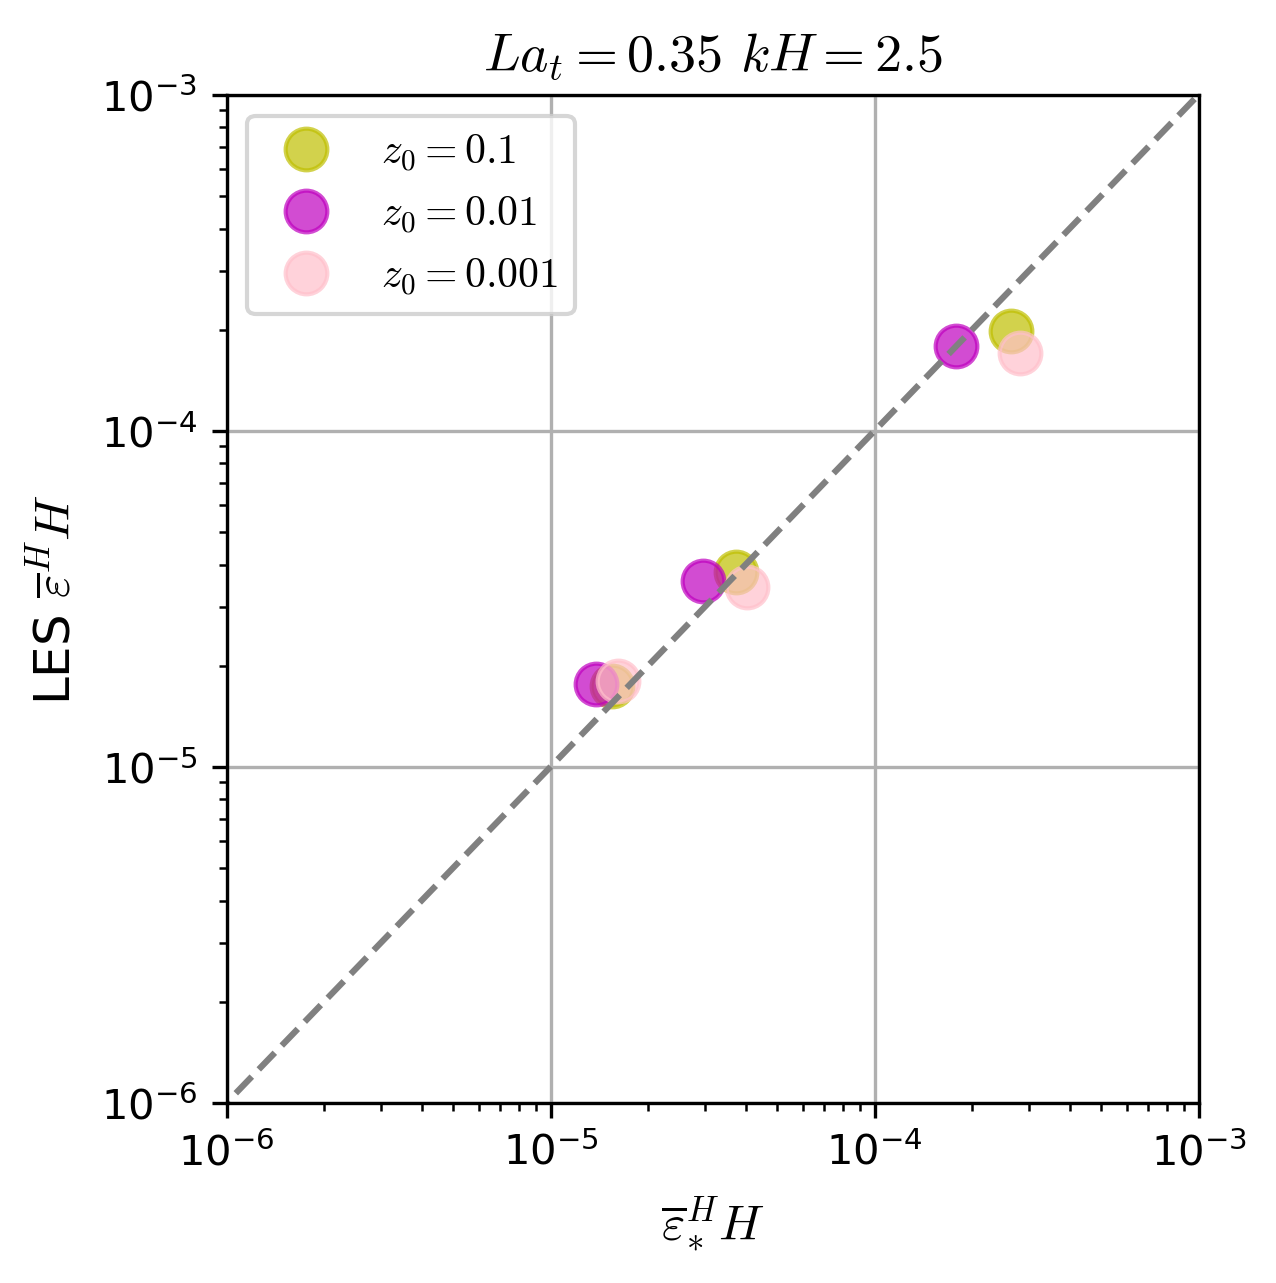

In [28]:
plt.rcParams['mathtext.fontset'] = 'cm'
ifig=0
fig=plt.figure(ifig,figsize=(4,4),dpi=300)
min=1e-6
max=1e-3

ax1=plt.subplot(111)

ax1.loglog(dissip_fitting_01[0:3],dissip_les_01[0:3],linewidth =1.5, color='y',
             linestyle='none',alpha=0.7,marker='o',markersize=10,label='$z_0=0.1$')

# ax1.loglog(dissip_fitting_01[1],dissip_les_01[1],linewidth =1.5, color='y',
#              linestyle='none',alpha=0.7,marker='^',markersize=10,label='$\chi=1$'+' '+ '$z_0=0.1$')

# ax1.loglog(dissip_fitting_01[2],dissip_les_01[2],linewidth =1.5, color='y',
#              linestyle='none',alpha=0.7,marker='s',markersize=10,label='$\chi=2$'+' '+ '$z_0=0.1$')

ax1.loglog(dissip_fitting_001[0:3],dissip_les_001[0:3],linewidth =1.5, color='m',
             linestyle='none',alpha=0.7,marker='o',markersize=10,label='$z_0=0.01$')

# ax1.loglog(dissip_fitting_001[1],dissip_les_001[1],linewidth =1.5, color='m',
#              linestyle='none',alpha=0.7,marker='^',markersize=10,label='$\chi=1$'+' '+'$z_0=0.01$')

# ax1.loglog(dissip_fitting_001[2],dissip_les_001[2],linewidth =1.5, color='m',
#              linestyle='none',alpha=0.7,marker='s',markersize=10,label='$\chi=2$'+' '+'$z_0=0.01$')

ax1.loglog(dissip_fitting_0001[0:3],dissip_les_0001[0:3],linewidth =1.5, color='pink',
             linestyle='none',alpha=0.7,marker='o',markersize=10,label='$z_0=0.001$')

# ax1.loglog(dissip_fitting_0001[1],dissip_les_0001[1],linewidth =1.5, color='pink',
#              linestyle='none',alpha=0.7,marker='^',markersize=10,label='$\chi=1$'+' '+'$z_0=0.001$')

# ax1.loglog(dissip_fitting_0001[2],dissip_les_0001[2],linewidth =1.5, color='pink',
#              linestyle='none',alpha=0.7,marker='s',markersize=10,label='$\chi=2$'+' '+'$z_0=0.001$')
diag_line = ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.legend()
ax1.set_ylim([min,max])
ax1.set_xlim([min,max])
ax1.set_ylabel(r"LES $\overline{\varepsilon}^H H$",fontsize=12,labelpad=5)
ax1.set_title('$La_t=0.35$'+' '+'$kH=2.5$',fontsize=13)
ax1.set_xlabel(r"$\overline{\varepsilon}_{*}^H H$",fontsize=12,labelpad=5)
ax1.grid(True)

fig.subplots_adjust(
    left=0.16,
    right=0.97,
    bottom=0.15,
    top=0.99
)
fig.savefig('test_z0',bbox_inches='tight')
plt.show()


In [2]:
ub_01=np.array([0.64592582, 0.30186364, 0.14657583])
ub_001=np.array([0.56501705, 0.26856373, 0.1212256])
ub_0001=np.array([0.66003297, 0.31280833, 0.15502648])

In [6]:
nz = 101
H = 25 # m
z=np.arange(-nz+1,1,1)/nz*H
z001=0.01
z0001=0.001
z01=0.1
κ = 0.4

In [31]:
delta_u1=(ub_0001-ub_001)#lat0.35 kH2.5 0,3,6,9,12
delta_u2=(ub_01-ub_001)
delta_u3=(ub_0001-ub_01)

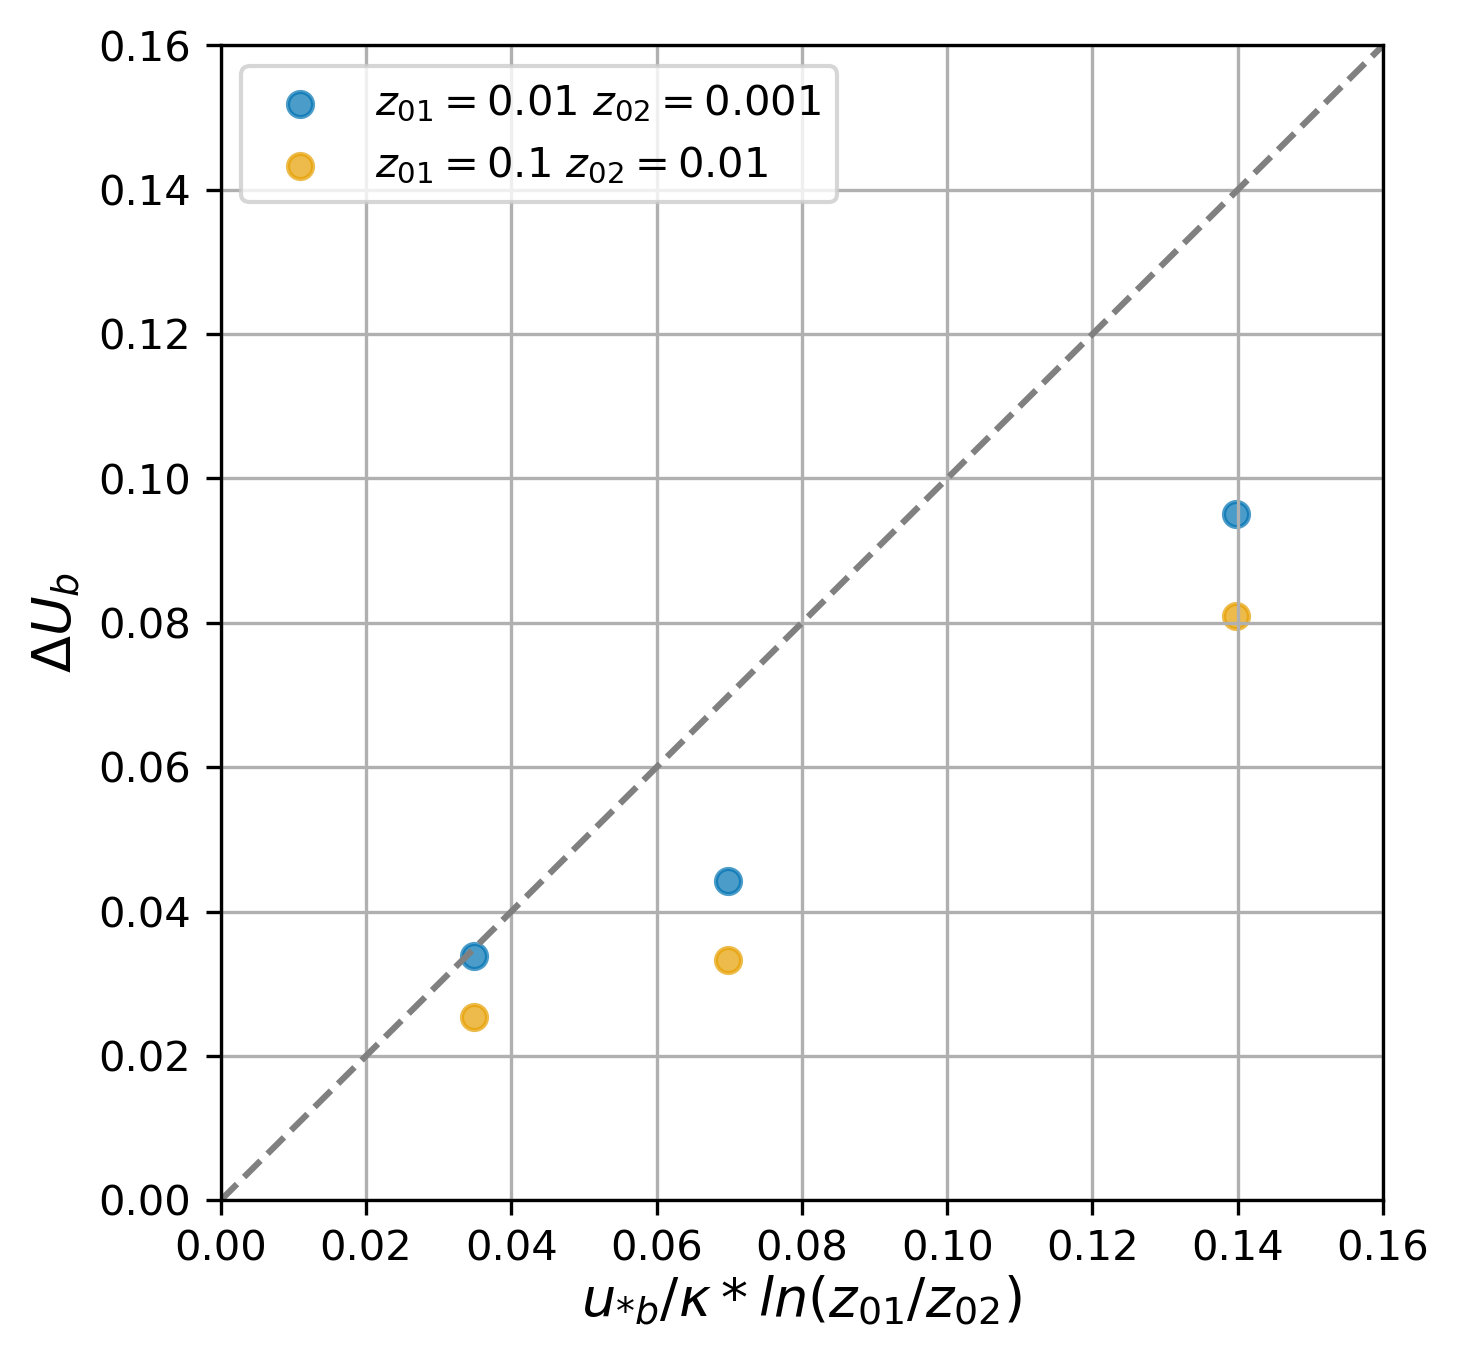

In [56]:
ifig=0
fig=plt.figure(ifig,figsize=(5,5),dpi=300)
min=0
max=0.16


ax1=fig.add_subplot(111)
# ax1.scatter(X,Y)
ax1.scatter(ustar_b/κ*np.log(z001/z0001),delta_u1, color=[0.0, 0.447, 0.698],
             label='$z_{01}=0.01$'+' '+'$z_{02}=0.001$',alpha=0.7,marker='o')
ax1.scatter(ustar_b/κ*np.log(z01/z001),delta_u2, color=[0.902, 0.624, 0.0],
             label='$z_{01}=0.1$'+' '+'$z_{02}=0.01$',alpha=0.7,marker='o')
# ax1.scatter(ustar_b/κ*np.log(z01/z0001),delta_u3, color=[0.436, 0.308, 0.631],
             # label='$z_{01}=0.1$'+' '+'$z_{02}=0.001$',alpha=0.7,marker='o')
diag_line = ax1.plot([0, 2000], [0, 2000], color='gray', linestyle='--')
ax1.set_ylim([min,max])
ax1.set_xlim([min,max])
ax1.set_ylabel("$\Delta U_b$",fontsize=13)

ax1.set_xlabel(r"$u_{*b}/\kappa*ln(z_{01}/z_{02})$",fontsize=13,labelpad=1)
plt.legend()
ax1.grid(True)


fig.savefig('test loglaw',bbox_inches='tight')
plt.show()

In [35]:
ustar_b/κ*np.log(z01/z0001)

array([0.27953383, 0.13976692, 0.06988346])

In [42]:
delta_u3

array([0.01410715, 0.01094469, 0.00845065])